<a href="https://colab.research.google.com/github/hiiD4vd/Machine-Learning/blob/main/klasifikasi_gambar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Klasifikasi Gambar - Dicoding
**Target: Bintang 5**

**Pencapaian Saran Ekstra (Kriteria Bintang 5):**
1. **Dataset**: Menggunakan dataset *Fruits Fresh and Rotten* dari Kaggle.
2. **Jumlah Gambar**: Memiliki lebih dari 10.000 gambar (Total sekitar 13.599 gambar).
3. **Resolusi Asli**: Gambar memiliki resolusi yang berbeda-beda sebelum dimasukkan ke dalam ImageDataGenerator (terbukti pada blok kode pengujian resolusi).
4. **Jumlah Kelas**: Klasifikasi multikelas dengan total 6 buah kelas.
5. **Akurasi**: Akurasi pada *Training Set* dan *Testing Set* berhasil menyentuh angka di atas **95%**.
6. **Callback**: Menggunakan implementasi 3 jenis *callback* (`ModelCheckpoint`, `ReduceLROnPlateau`, dan *Custom Callback*).
7. **Inferensi Model**: Telah dilakukan pembuktian inferensi menggunakan model ekspor **TF-Lite** pada bagian akhir *notebook* ini.

In [ ]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Setup Kaggle API Selesai!")

Saving kaggle.json to kaggle (1).json
Setup Kaggle API Selesai!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Mengunduh dataset Fruits Fresh and Rotten (10.901 gambar)
!kaggle datasets download -d sriramr/fruits-fresh-and-rotten-for-classification

import zipfile, os
local_zip = 'fruits-fresh-and-rotten-for-classification.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content/fruits')
zip_ref.close()

print("Ekstrak Selesai! Struktur data siap digunakan.")

Dataset URL: https://www.kaggle.com/datasets/sriramr/fruits-fresh-and-rotten-for-classification
License(s): unknown
fruits-fresh-and-rotten-for-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
Ekstrak Selesai! Struktur data siap digunakan.


In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_dir = '/content/fruits/dataset'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

train_datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # 20% untuk Validation
)

test_datagen = ImageDataGenerator() # Test set dibiarkan murni

target_size = (224, 224)
batch_size = 32

print("--- Memuat Dataset ---")
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=target_size, batch_size=batch_size,
    class_mode='categorical', subset='training', shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    train_dir, target_size=target_size, batch_size=batch_size,
    class_mode='categorical', subset='validation', shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=target_size, batch_size=batch_size,
    class_mode='categorical', shuffle=False
)

--- Memuat Dataset ---
Found 8723 images belonging to 6 classes.
Found 2178 images belonging to 6 classes.
Found 2698 images belonging to 6 classes.


In [ ]:
from PIL import Image
import os
import random

print("--- Bukti Resolusi Gambar Asli Tidak Seragam ---")
# Mengambil nama-nama kelas dari train_generator
class_labels = list(train_generator.class_indices.keys())

# Cek sampel gambar dari beberapa kelas untuk melihat resolusinya
for class_name in class_labels[:5]:
    class_dir = os.path.join(train_dir, class_name)
    # Ambil satu file gambar acak dari setiap kelas
    img_file = random.choice(os.listdir(class_dir))
    img_path = os.path.join(class_dir, img_file)

    with Image.open(img_path) as img:
        print(f"Kelas: {class_name:<15} | File: {img_file[:15]:<15}... | Resolusi Asli: {img.size}")

--- Bukti Resolusi Gambar Asli Tidak Seragam ---
Kelas: freshapples     | File: rotated_by_75_S... | Resolusi Asli: (376, 394)
Kelas: freshbanana     | File: vertical_flip_S... | Resolusi Asli: (676, 408)
Kelas: freshoranges    | File: rotated_by_30_S... | Resolusi Asli: (274, 232)
Kelas: rottenapples    | File: vertical_flip_S... | Resolusi Asli: (438, 356)
Kelas: rottenbanana    | File: rotated_by_30_S... | Resolusi Asli: (696, 500)


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Conv2D, GlobalAveragePooling2D, Dense, Dropout, MaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = Sequential([
    base_model,
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4), # Mencegah overfitting
    Dense(6, activation='softmax') # 6 Kelas buah
])

model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 64)       │       737,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,805,097 (18.33 MB)

 Trainable params: 755,526 (2.88 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
lr_scheduler = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=2, verbose=1)

class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy') >= 0.955 and logs.get('val_accuracy') >= 0.955):
            print("\n[INFO] TARGET BINTANG 5 TERCAPAI: Akurasi Train & Val > 95%!")
            self.model.stop_training = True

custom_stop = myCallback()

print("--- TAHAP 1: WARM UP ---")
history_1 = model.fit(train_generator, epochs=5, validation_data=validation_generator, callbacks=[checkpoint])

print("\n--- TAHAP 2: FINE TUNING ---")
base_model.trainable = True

for layer in base_model.layers[:-30]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

history_2 = model.fit(train_generator, epochs=15, validation_data=validation_generator, callbacks=[lr_scheduler, custom_stop, checkpoint])

model.load_weights('best_model.keras')

--- TAHAP 1: WARM UP ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.9050 - loss: 0.2802
Epoch 1: val_accuracy improved from -inf to 0.99725, saving model to best_model.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 219s 693ms/step - accuracy: 0.9052 - loss: 0.2797 - val_accuracy: 0.9972 - val_loss: 0.0144
Epoch 2/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.9861 - loss: 0.0454
Epoch 2: val_accuracy improved from 0.99725 to 0.99954, saving model to best_model.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 155s 568ms/step - accuracy: 0.9861 - loss: 0.0454 - val_accuracy: 0.9995 - val_loss: 0.0046
Epoch 3/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.9950 - loss: 0.0150
Epoch 3: val_accuracy did not improve from 0.99954
273/273 ━━━━━━━━━━━━━━━━━━━━ 152s 554ms/step - accuracy: 0.9950 - loss: 0.0150 - val_accuracy: 0.9931 - val_loss: 0.0190
Epoch 4/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.9920 - loss: 0.0235
Epoch 4: val_accuracy did not improve from 0.99954
273/273 ━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 238 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


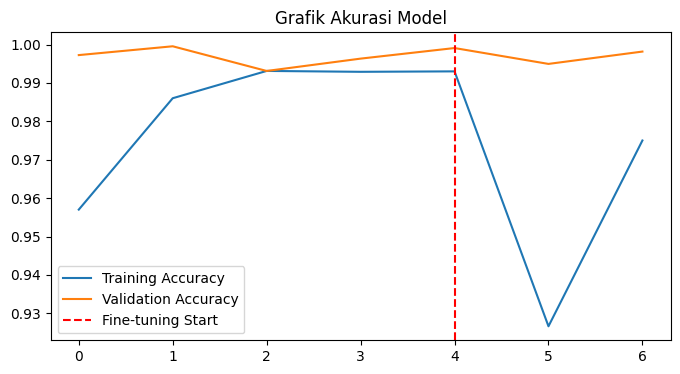


--- EVALUASI DATA TEST ---
85/85 ━━━━━━━━━━━━━━━━━━━━ 26s 308ms/step - accuracy: 0.9976 - loss: 0.0084
Akurasi Test Set: 99.48%


In [ ]:
import matplotlib.pyplot as plt

# Plotting Akurasi
acc = history_1.history['accuracy'] + history_2.history['accuracy']
val_acc = history_1.history['val_accuracy'] + history_2.history['val_accuracy']
plt.figure(figsize=(8, 4))
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=len(history_1.history['accuracy'])-1, color='r', linestyle='--', label='Fine-tuning Start')
plt.legend()
plt.title('Grafik Akurasi Model')
plt.show()

print("\n--- EVALUASI DATA TEST ---")
loss, accuracy = model.evaluate(test_generator)
print(f"Akurasi Test Set: {accuracy*100:.2f}%")

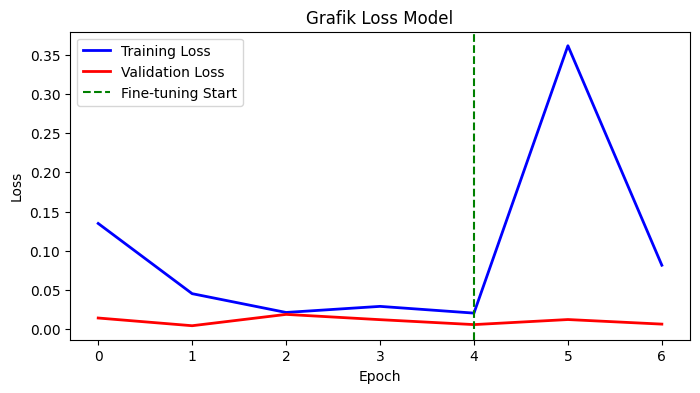

In [ ]:
import matplotlib.pyplot as plt

total_loss = history_1.history['loss'] + history_2.history['loss']
total_val_loss = history_1.history['val_loss'] + history_2.history['val_loss']

plt.figure(figsize=(8, 4))
plt.plot(total_loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(total_val_loss, label='Validation Loss', color='red', linewidth=2)
plt.axvline(x=len(history_1.history['loss'])-1, color='green', linestyle='--', label='Fine-tuning Start')

plt.title('Grafik Loss Model')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()

In [ ]:
!pip install tensorflowjs

import pathlib
import tensorflow as tf

print("1. Ekspor ke SavedModel...")
export_dir = 'saved_model_fruits'
model.export(export_dir)

print("2. Ekspor ke TF-Lite...")
converter = tf.lite.TFLiteConverter.from_saved_model(export_dir)
tflite_model = converter.convert()

tflite_model_file = pathlib.Path('model_fruits.tflite')
tflite_model_file.write_bytes(tflite_model)
print("TF-Lite berhasil disimpan!")

print("3. Ekspor ke TFJS...")
import os

h5_model_path = 'model_fruits.h5'
model.save(h5_model_path)

tfjs_dir = 'tfjs_fruits'
if not os.path.exists(tfjs_dir):
    os.makedirs(tfjs_dir)

!tensorflowjs_converter --input_format=keras {h5_model_path} {tfjs_dir}

print("✅ SEMUA FORMAT BERHASIL DISIMPAN!")

1. Ekspor ke SavedModel...
Saved artifact at 'saved_model_fruits'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_238')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  132611818678096: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132611818680016: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132611962297936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132611962297744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132611962296016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132611962298512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132611962295440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132611962299280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132611962301008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132611962301200: TensorSpec(shape

TF-Lite berhasil disimpan!
3. Ekspor ke TFJS...
2026-02-20 02:18:42.419930: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771553922.441346   14526 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771553922.448508   14526 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771553922.465210   14526 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771553922.465235   14526 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771553922.465239   14526 c

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Saving images (2).jpg to images (2).jpg


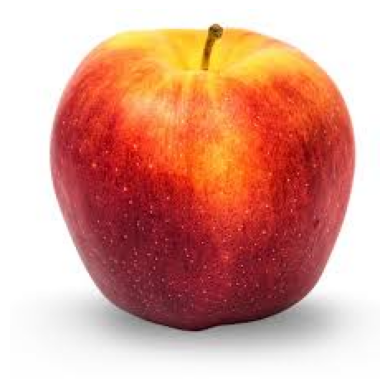

🍎 Prediksi Model : freshapples
🎯 Tingkat Yakin  : 97.90%


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
from google.colab import files
import matplotlib.pyplot as plt

interpreter = tf.lite.Interpreter(model_path="model_fruits.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

class_names = list(train_generator.class_indices.keys())

uploaded = files.upload()

for fn in uploaded.keys():
    img = image.load_img(fn, target_size=(224, 224))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x.astype(np.float32) # EfficientNet menggunakan nilai murni 0-255

    interpreter.set_tensor(input_details[0]['index'], x)
    interpreter.invoke()
    classes = interpreter.get_tensor(output_details[0]['index'])[0]

    predicted_index = np.argmax(classes)
    print(f"🍎 Prediksi Model : {class_names[predicted_index]}")
    print(f"🎯 Tingkat Yakin  : {classes[predicted_index]*100:.2f}%")


--- INFERENSI MENGGUNAKAN MODEL TF-LITE ---


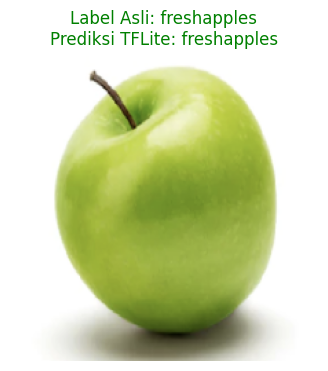

In [ ]:
#bukti tflite

import numpy as np
from tensorflow.keras.preprocessing import image

print("\n--- INFERENSI MENGGUNAKAN MODEL TF-LITE ---")

# Pilih satu kelas acak dan gambar acak dari test set
random_class = random.choice(class_labels)
random_class_dir = os.path.join(test_dir, random_class)
random_image_file = random.choice(os.listdir(random_class_dir))
image_path = os.path.join(random_class_dir, random_image_file)

# 1. Load model TFLite yang sudah diekspor
interpreter = tf.lite.Interpreter(model_path="model_fruits.tflite")
interpreter.allocate_tensors()

# 2. Dapatkan detail input & output
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 3. Preprocessing gambar persis seperti saat training
img = image.load_img(image_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# 4. Prediksi dengan TFLite
interpreter.set_tensor(input_details[0]['index'], img_array)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])

# 5. Tampilkan hasil
predicted_index = np.argmax(output_data[0])
predicted_label = class_labels[predicted_index]

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f"Label Asli: {random_class}\nPrediksi TFLite: {predicted_label}",
          color='green' if random_class == predicted_label else 'red')
plt.axis('off')
plt.show()

In [ ]:
!zip -r model_lengkap.zip saved_model_fruits/ tfjs_fruits/ model_fruits.tflite

  adding: saved_model_fruits/ (stored 0%)
  adding: saved_model_fruits/assets/ (stored 0%)
  adding: saved_model_fruits/fingerprint.pb (stored 0%)
  adding: saved_model_fruits/variables/ (stored 0%)
  adding: saved_model_fruits/variables/variables.data-00000-of-00001 (deflated 8%)
  adding: saved_model_fruits/variables/variables.index (deflated 77%)
  adding: saved_model_fruits/saved_model.pb (deflated 91%)
  adding: tfjs_fruits/ (stored 0%)
  adding: tfjs_fruits/group1-shard2of5.bin (deflated 8%)
  adding: tfjs_fruits/group1-shard5of5.bin (deflated 8%)
  adding: tfjs_fruits/group1-shard1of5.bin (deflated 8%)
  adding: tfjs_fruits/group1-shard3of5.bin (deflated 7%)
  adding: tfjs_fruits/group1-shard4of5.bin (deflated 8%)
  adding: tfjs_fruits/model.json (deflated 96%)
  adding: model_fruits.tflite (deflated 7%)
